# Assignment 2 Recognition using histograms, convolution, and image filtering

## Exercise 1: Convolution

In [1]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
from a2_utils import *
from assignment2.a2_utils import gauss_noise

I = read_data('signal.txt')
k = read_data('kernel.txt')

In [38]:
def simple_convolution(signal, kernel):
    N = (len(kernel) - 1) // 2
    I_length = len(signal)
    result = np.zeros(I_length - 2 * N)

    for i in range(N, I_length - N):
        for j in range (len(kernel)):
            result[i - N] += kernel[j] * signal[i - j + N]

    return result, N


0.9999999974


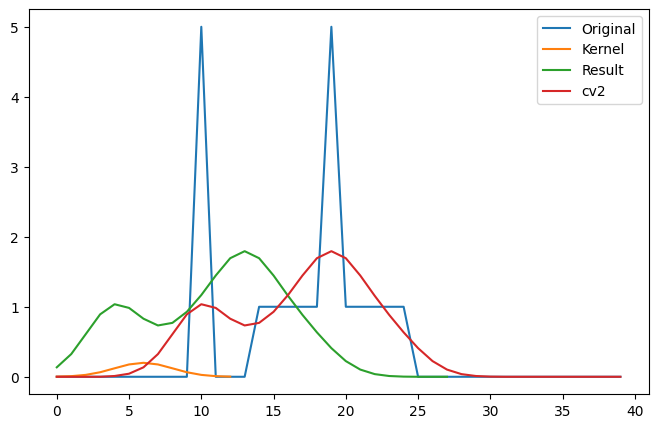

In [39]:
convolution, N = simple_convolution(I, k)
# print(convolution)
test = cv2.filter2D(I, -1, k[::-1].reshape((-1, 1)).flatten())
# print(test)
print(k.sum())

plt.figure(figsize=(8,5))
plt.plot(I, label='Original')
plt.plot(k, label='Kernel')
plt.plot(convolution, label='Result')
plt.plot(test, label='cv2')

plt.legend()
plt.show()

**Question: Can you recognize the shape of the kernel? What is the sum of the
elements in the kernel? How does the kernel affect the signal?**
Yes I can recognize the shape of the kernel, it's a small bell-like shape - a Gaussian kernel. The sum of the kernel is approximately 1, which means it is normalized and preserves the overall intensity of the signal. The kernel smooths the signal. It reduces sharp peaks and noise.

In [40]:
def padding(signal, N):
    left = signal[N:0:-1] # N elementov levo od začetka signala
    right = signal[-2:-N-2:-1] # N el. desno od konca signala
    return np.concatenate((left, signal, right))

In [41]:
def simple_convolution2(signal, kernel):
    N = (len(kernel) - 1) // 2
    I_length = len(signal)

    result = np.zeros(I_length, dtype=float)
    # padded = np.pad(signal, (N, N), mode='reflect')
    padded = padding(signal, N)
    k = kernel[::-1]

    for i in range(I_length):
        window = padded[i : i + len(k)]
        result[i] = np.dot(k, window).item()

    return result


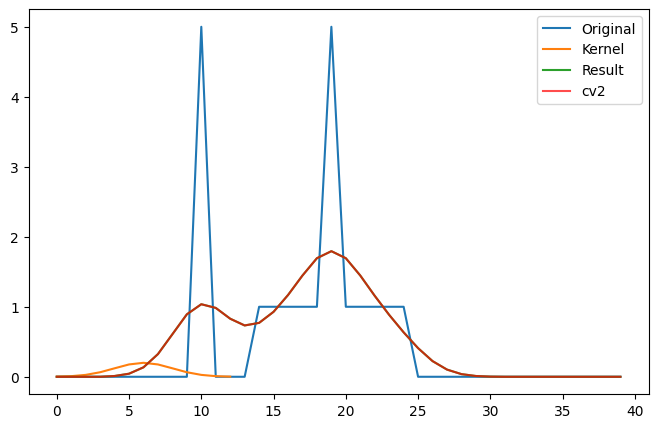

In [42]:
convolution = simple_convolution2(I, k)
test = cv2.filter2D(I, -1, k[::-1].reshape((-1, 1)), borderType=cv2.BORDER_REFLECT_101).flatten()

plt.figure(figsize=(8,5))
plt.plot(I, label='Original')
plt.plot(k, label='Kernel')
plt.plot(convolution, label='Result')
plt.plot(test, label='cv2', color='red', alpha=0.7)

plt.legend()
plt.show()


In [43]:
def gauss(sigma):
    radius = int(np.ceil(3*sigma))
    g = np.zeros(2 * radius + 1, dtype=float)
    x = np.arange(-radius, radius + 1, dtype=float)
    g = (1 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-(x**2) / (2 * sigma**2))
    g /= g.sum()
    return x, g

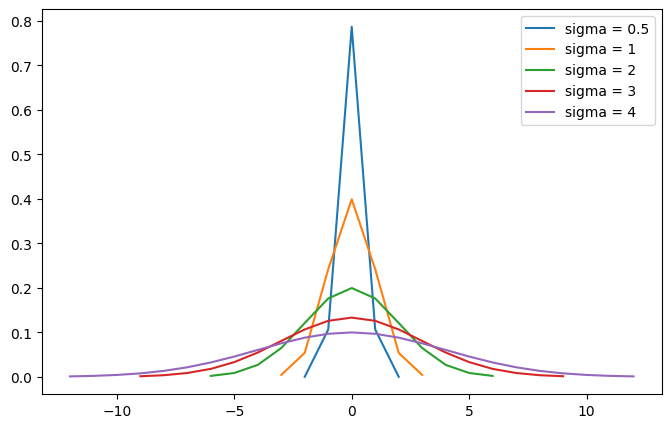

In [44]:
plt.figure(figsize=(8,5))
x, y = gauss(0.5)
plt.plot(x, y, label='sigma = 0.5')
x, y = gauss(1)
plt.plot(x, y, label='sigma = 1')
x, y = gauss(2)
plt.plot(x, y, label='sigma = 2')
x, y = gauss(3)
plt.plot(x, y, label='sigma = 3')
x, y = gauss(4)
plt.plot(x, y, label='sigma = 4')

plt.legend()
plt.show()

Text(0.5, 1.0, 's * (k3 * k3)')

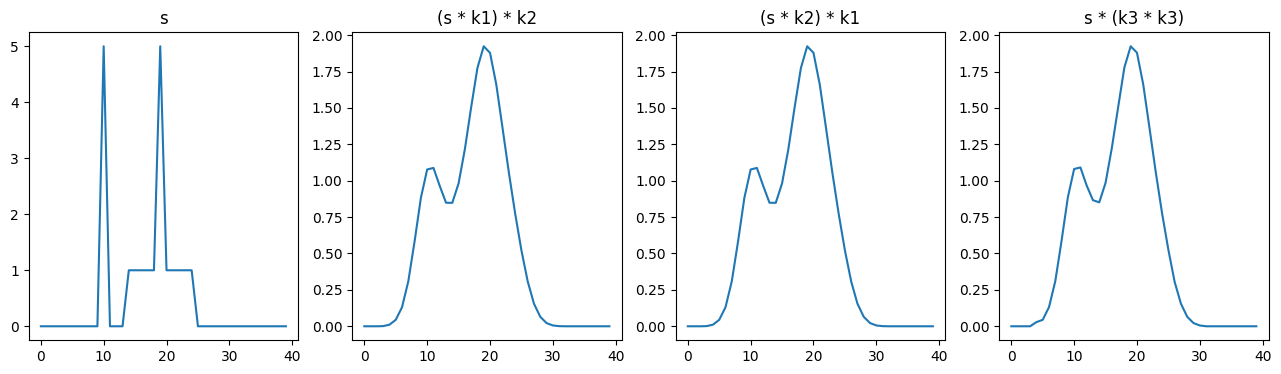

In [45]:
_, k1 = gauss(2)
k2 = [0.1, 0.6, 0.4]
convolution1 = simple_convolution2(I, k1)
convolution2 = simple_convolution2(convolution1, k2)

convolution3 = simple_convolution2(I, k2)
convolution4 = simple_convolution2(convolution3, k1)

k3 = simple_convolution2(k1, k2)
convolution5 = simple_convolution2(I, k3)

fig, axs = plt.subplots(1, 4, figsize=(16,4))
axs[0].plot(I)
axs[0].set_title('s')

axs[1].plot(convolution2)
axs[1].set_title('(s * k1) * k2')

axs[2].plot(convolution4)
axs[2].set_title('(s * k2) * k1')

axs[3].plot(convolution5)
axs[3].set_title('s * (k3 * k3)')


## Exercise 2: Image filtering

In [46]:
def gaussfilter(image):
    sigma = 2
    _, k = gauss(sigma)

    kernel_row = np.expand_dims(k, 0)
    kernel_column = kernel_row.T

    tmp = cv2.filter2D(image, -1, kernel_row)
    filtered = cv2.filter2D(tmp, -1, kernel_column)

    return filtered


Text(0.5, 1.0, 'Filtered Salt-and-pepper noise')

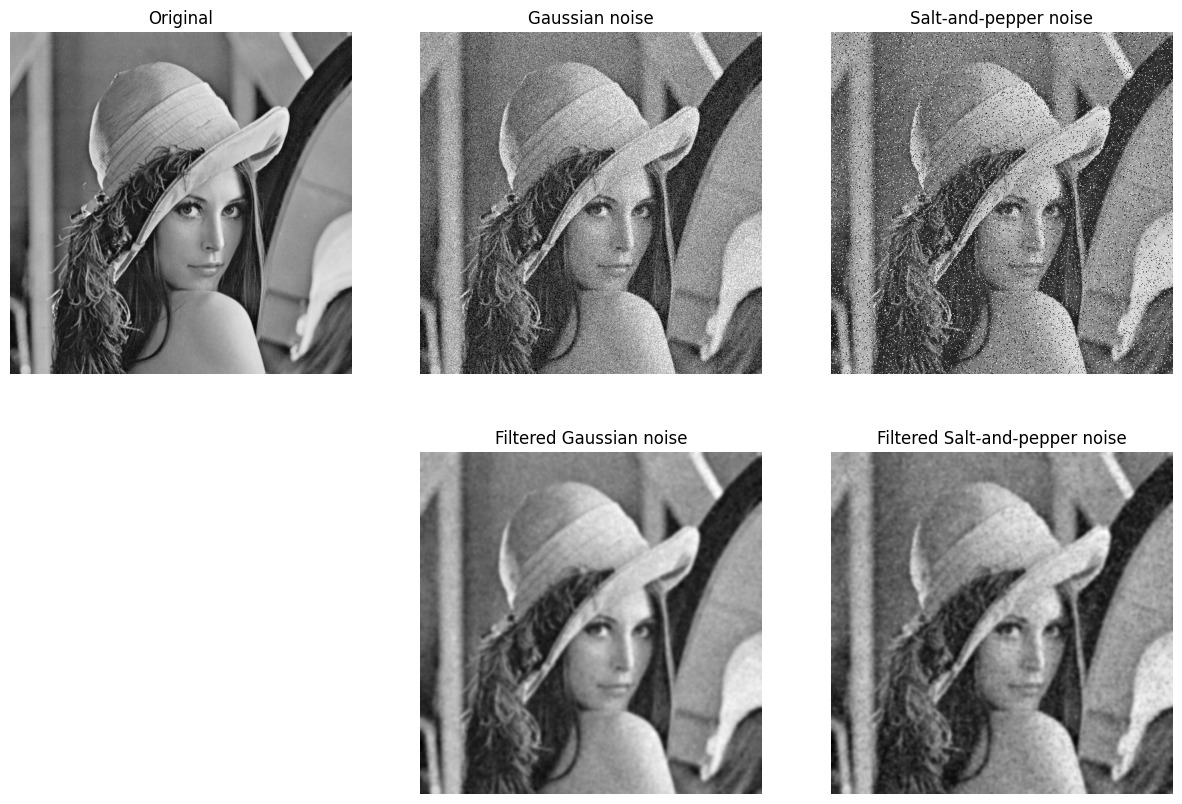

In [47]:
lena = cv2.imread('./images/lena.png')
lena_gray = cv2.cvtColor(lena, cv2.COLOR_BGR2GRAY)
lena_gray = lena_gray / 255

plt.figure(figsize=(15,10))
plt.subplot(2, 3, 1)
plt.imshow(lena_gray, cmap='gray')
plt.axis('off')
plt.title('Original')

noisy_lena = gauss_noise(lena_gray, magnitude=0.1)
plt.subplot(2, 3, 2)
plt.imshow(noisy_lena, cmap='gray')
plt.axis('off')
plt.title('Gaussian noise')

sp_lena = sp_noise(lena_gray, percent=0.1)
plt.subplot(2, 3, 3)
plt.imshow(sp_lena, cmap='gray')
plt.axis('off')
plt.title('Salt-and-pepper noise')

filtered_gaussian = gaussfilter(noisy_lena)
plt.subplot(2, 3, 5)
plt.imshow(filtered_gaussian, cmap='gray')
plt.axis('off')
plt.title('Filtered Gaussian noise')

filtered_sp = gaussfilter(sp_lena)
plt.subplot(2, 3, 6)
plt.imshow(filtered_sp, cmap='gray')
plt.axis('off')
plt.title('Filtered Salt-and-pepper noise')

**Question: Which noise is better removed using the Gaussian filter?**
The Gaussian noise.

In [48]:
def sharpen(image):
    first = np.array([
        [0, 0, 0],
        [0, 2, 0],
        [0, 0, 0],
    ])
    second = np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
    ])

    k = first - (1 / 9) * second
    return cv2.filter2D(image, -1, k)



(np.float64(-0.5), np.float64(499.5), np.float64(374.5), np.float64(-0.5))

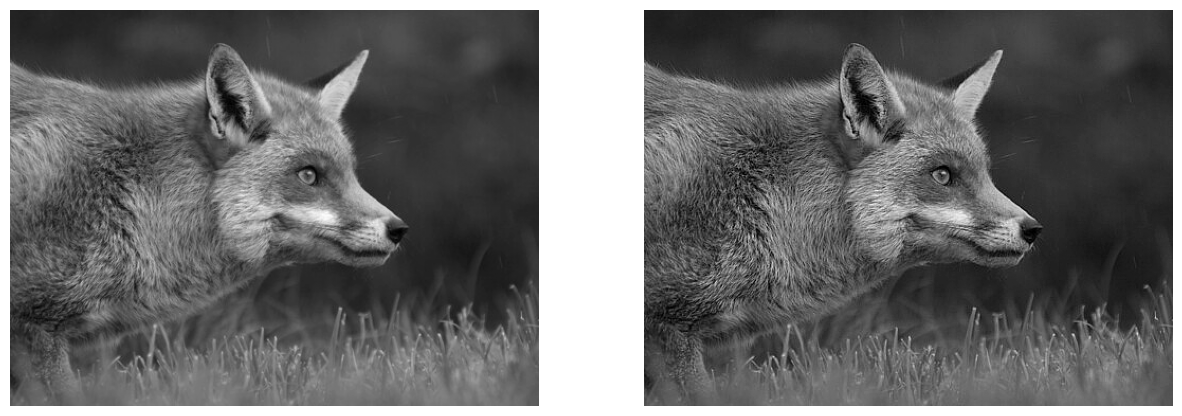

In [49]:
fox = cv2.imread('./images/fox.jpg')
fox_gray = cv2.cvtColor(fox, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(15,14))
plt.subplot(2, 2, 1)
plt.imshow(fox_gray, cmap='gray')
plt.axis('off')

sharpened_fox = sharpen(fox_gray)
plt.subplot(2, 2, 2)
plt.imshow(sharpened_fox, cmap='gray')
plt.axis('off')

In [50]:
def simple_median(I, w):
    r = ( w - 1 ) // 2
    N = len(I)
    padded_I = np.pad(I, (r, r), mode='reflect')
    filtered_signal = np.zeros(N, dtype=float)

    for i in range(N):
        window = padded_I[i : i + w]
        filtered_signal[i] = np.median(window)

    return filtered_signal

Text(0.5, 1.0, 'Median')

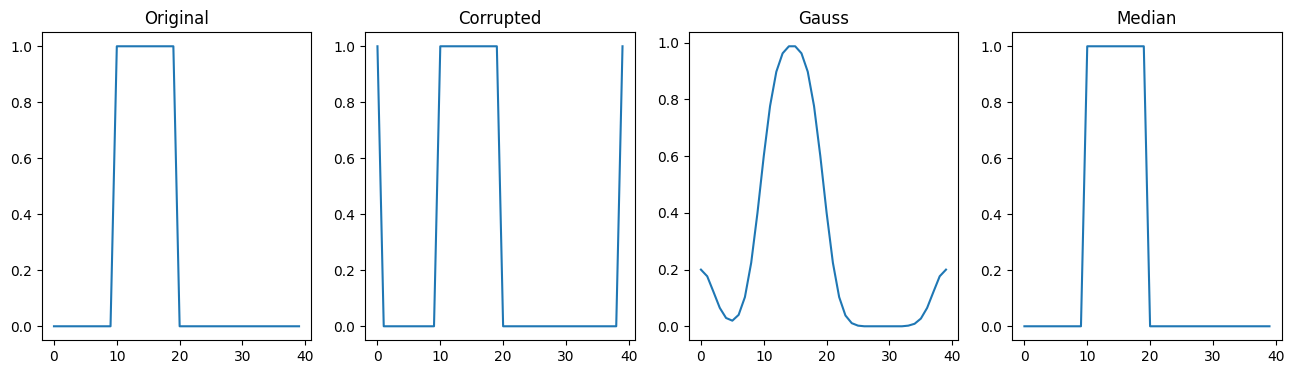

In [51]:
fig, axs = plt.subplots(1, 4, figsize=(16,4))
# I2 = read_data('signal.txt')
# I2 = I2.astype('float') / np.max(I2)
I2 = np.zeros(40)
I2[10:20] = 1

axs[0].plot(I2)
axs[0].set_title('Original')

I_extend = np.expand_dims(I2, axis=1)
corrupted = sp_noise(I_extend, percent=0.1)
_, g = gauss(2)
gauss_fix = simple_convolution2(corrupted, g)
median_fix = simple_median(corrupted.flatten(), 5)

axs[1].plot(corrupted)
axs[1].set_title('Corrupted')

axs[2].plot(gauss_fix)
axs[2].set_title('Gauss')

axs[3].plot(median_fix)
axs[3].set_title('Median')

**Question: Which filter performs better at this specific task? In comparison to
Gaussian filter that can be applied multiple times in any order, does the order
matter in case of median filter? What is the name of filters like this?**
The median filter performs better. Yes the order can matter, because it is non linear. Non-linear filters.


In [52]:
def median_filter(image, w):
    r = ( w - 1 ) // 2
    padded_img = np.pad(image, ((r, r), (r, r)), mode='reflect')
    filtered_image = np.zeros(image.shape, dtype=float)

    for i in range(image.shape[0]):
        for j in range (image.shape[1]):
            window = padded_img[i : i + w, j : j + w]
            filtered_image[i][j] = np.median(window)

    return filtered_image

Text(0.5, 1.0, 'Filtered Salt-and-pepper noise')

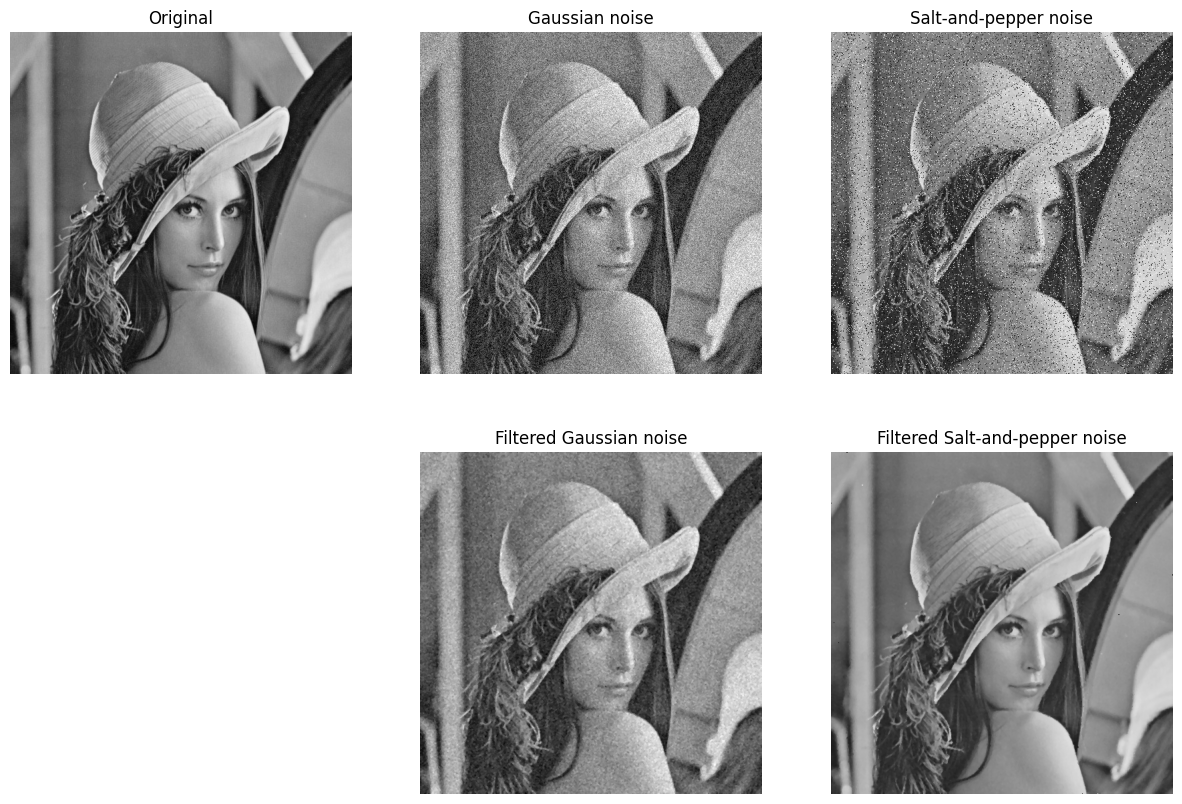

In [53]:
plt.figure(figsize=(15,10))
plt.subplot(2, 3, 1)
plt.imshow(lena_gray, cmap='gray')
plt.axis('off')
plt.title('Original')

noisy_lena = gauss_noise(lena_gray, magnitude=0.1)
plt.subplot(2, 3, 2)
plt.imshow(noisy_lena, cmap='gray')
plt.axis('off')
plt.title('Gaussian noise')

sp_lena = sp_noise(lena_gray, percent=0.1)
plt.subplot(2, 3, 3)
plt.imshow(sp_lena, cmap='gray')
plt.axis('off')
plt.title('Salt-and-pepper noise')

w = 3
median_filtered_gaussian = median_filter(noisy_lena, w)
plt.subplot(2, 3, 5)
plt.imshow(median_filtered_gaussian, cmap='gray')
plt.axis('off')
plt.title('Filtered Gaussian noise')

median_filtered_sp = median_filter(sp_lena, w)
plt.subplot(2, 3, 6)
plt.imshow(median_filtered_sp, cmap='gray')
plt.axis('off')
plt.title('Filtered Salt-and-pepper noise')

**Question: What is the computational complexity of the Gaussian filter operation?
How about the median filter? What does it depend on? Describe the computational
complexity using the O(·) notation (you can assume n log n complexity for sorting).**
The Gaussian filter has a computational complexity of O(k^2*n) where k is the kernel size and n is the number of pixels. But it can be faster O(k*n).
The median filter has a higher complexity of O(k*logk*n), since it must sort the pixel values within each window.
Therefore, the Gaussian filter is faster, while the median filter is more computationally expensive but better at removing salt-and-pepper noise.

## Exercise 3: Global approach to image description

In [54]:
def myhist3(image, n_bins):
    R = image[:,:,0].reshape(-1)
    G = image[:,:,1].reshape(-1)
    B = image[:,:,2].reshape(-1)

    H = np.zeros((n_bins, n_bins, n_bins))
    ir = np.clip(np.floor(R * n_bins)).astype(np.int64) # calculates the index of the bin that corresponds to the pixel color
    ig = np.clip(np.floor(G * n_bins)).astype(np.int64)
    ib = np.clip(np.floor(B * n_bins)).astype(np.int64)

    hist = ir * (n_bins * n_bins) + ig * n_bins + ib
    temp = np.bincount(hist, minlength=n_bins**3)
    H = temp.reshape(n_bins, n_bins, n_bins)

    H = H / H.sum()
    return H

In [55]:
def compare_histograms(hist1, hist2, operation):
    hist1 = np.asarray(hist1, dtype=np.float64).ravel()
    hist2 = np.asarray(hist2, dtype=np.float64).ravel()

    if operation == 'L2':
        distance = np.sqrt(np.sum((hist1 - hist2) ** 2))
        return distance
    elif operation == 'X2':
        e0 = 1e-10
        chi = 0.5 * np.sum(((hist1 - hist2) ** 2) / (hist1 + hist2 + e0))
        return chi
    elif operation == 'I':
        intersection = 1 - np.sum(np.minimum(hist1, hist2))
        return intersection
    elif operation == 'H':
        hellinger = np.sqrt(0.5 * np.sum((np.sqrt(hist1) - np.sqrt(hist2)) ** 2))
        return hellinger
    else:
        print("Invalid operation")
        return None


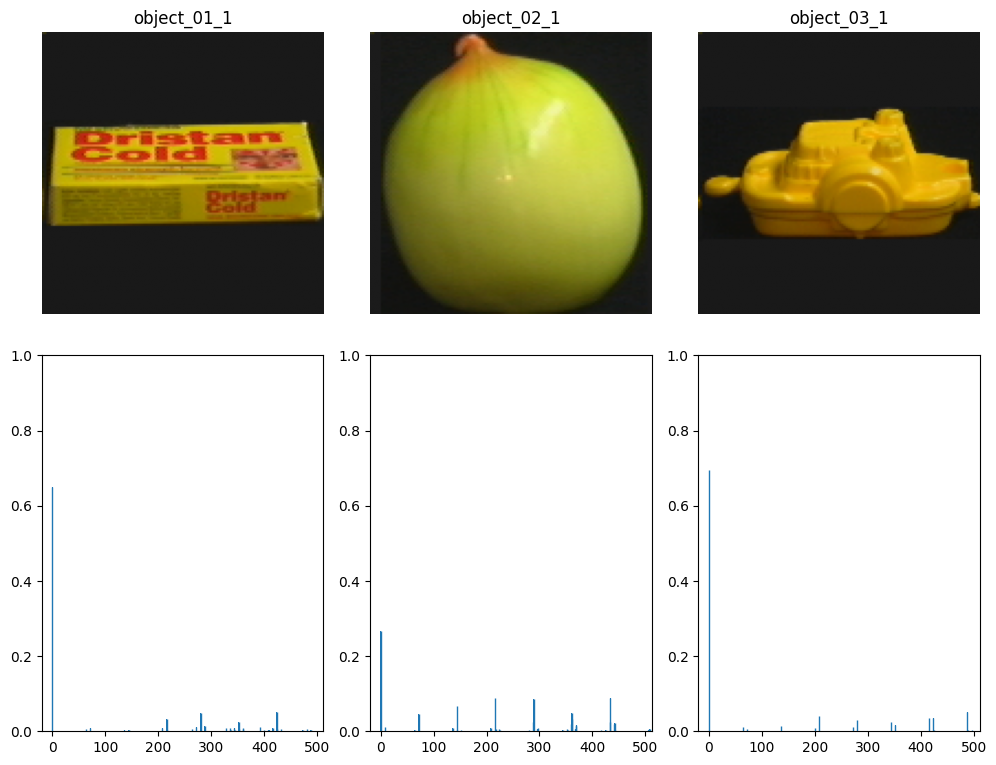

0.42630332471992644
0.09507866927455817
0.4321906396902619
0.6007080078125
0.5745452717010867
0.13073834412304272
0.197021484375
0.32069985954328856


In [56]:
object1 = cv2.imread('./dataset/object_01_1.png')
object1 = cv2.cvtColor(object1, cv2.COLOR_BGR2RGB)
object1 = object1.astype(float)/255.0
object2 = cv2.imread('./dataset/object_02_1.png')
object2 = cv2.cvtColor(object2, cv2.COLOR_BGR2RGB)
object2 = object2.astype(float)/255.0
object3 = cv2.imread('./dataset/object_03_1.png')
object3 = cv2.cvtColor(object3, cv2.COLOR_BGR2RGB)
object3 = object3.astype(float)/255.0

hist1 = myhist3(object1, 8).reshape(-1)
hist2 = myhist3(object2, 8).reshape(-1)
hist3 = myhist3(object3, 8).reshape(-1)


distance12 = compare_histograms(hist1, hist2, 'L2')
distance13 = compare_histograms(hist1, hist3, 'L2')

fig, axs = plt.subplots(2, 3, figsize=(10, 8))
axs[0, 0].imshow(object1)
axs[0, 0].set_title('object_01_1')
axs[0, 0].axis('off')

axs[0, 1].imshow(object2)
axs[0, 1].set_title('object_02_1')
axs[0, 1].axis('off')

axs[0, 2].imshow(object3)
axs[0, 2].set_title('object_03_1')
axs[0, 2].axis('off')

x1 = np.arange(hist1.size)
axs[1, 0].bar(x1, hist1, width=1.0)
axs[1, 0].vlines(x1, 0, hist1, linewidth=1.0)
x2 = np.arange(hist2.size)
axs[1, 1].bar(x2, hist2, width=1.0)
axs[1, 1].vlines(x2, 0, hist2, linewidth=1.0)
x3 = np.arange(hist3.size)
axs[1,2].bar(x3, hist3, width=1.0)
axs[1,2].vlines(x3, 0, hist3, linewidth=1.0)


for ax, h in zip(axs[1], [hist1, hist2, hist3]):
    ax.set_xlim(-20, h.size)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(distance12)
print(distance13)
print(compare_histograms(hist1, hist2, 'X2'))
print(compare_histograms(hist1, hist2, 'I'))
print(compare_histograms(hist1, hist2, 'H'))
print(compare_histograms(hist1, hist3, 'X2'))
print(compare_histograms(hist1, hist3, 'I'))
print(compare_histograms(hist1, hist3, 'H'))

**Question: Which image (object_02_1.png or object_03_1.png) is more similar to image object_01_1.png considering the L2 distance? How about the other three
distances? We can see that all three histograms contain a strongly expressed component (one bin has a much higher value than the others). Which color does this
bin represent?**
More similar is the second object since the L2 distance is smaller. The same image is the most similar. It represents the color black - so the background.

In [57]:
def save_info(path, n_bins):
    all_hists = []
    images = sorted([img for img in os.listdir(path) if img.endswith('.png')])
    for i in images:
        full_path = os.path.join(path, i)
        img = cv2.imread(full_path)
        img = (cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).astype(np.float64)/255.0
        hist = myhist3(img, n_bins).reshape(-1)
        all_hists.append(hist)
    all_hists = np.array(all_hists)
    names = np.array(images)
    parent_dir = os.path.dirname(path)
    np.save(os.path.join(parent_dir, 'histograms.npy'), all_hists)
    np.save(os.path.join(parent_dir, 'hist_names.npy'), names)

In [58]:
path = './dataset'
n_bins = 8
save_info(path, n_bins)

In [59]:
def compute_distances(histogram, metric, all_hists):
    distances = []
    distances = np.array([compare_histograms(histogram, h, metric) for h in all_hists])
    distances = np.array(distances)
    return distances


In [60]:
def compare_withAll(ref_hist, metric, all_hists):
    hist_names = np.load('hist_names.npy')
    dataset_dir = "./dataset"
    ref_name = "object_05_4.png"
    cols = 6
    N, D = all_hists.shape

    distances = compute_distances(ref_hist, metric, all_hists)

    order = np.argsort(distances)
    first5_idx = order[:6]
    first5_names = hist_names[first5_idx]
    first5_hists = all_hists[first5_idx]
    first5_dists = distances[first5_idx]

    fig, ax = plt.subplots(2, cols, figsize=(16, 6))

    for j, (name, d, h) in enumerate(zip(first5_names, first5_dists, first5_hists)):
        img = cv2.cvtColor(cv2.imread(os.path.join(dataset_dir, name)), cv2.COLOR_BGR2RGB).astype(np.float32)/255.0

        ax[0, j].imshow(img)
        ax[0, j].set_title(f"{name}\n{metric}: {d:.3f}", fontsize=10)

        ax[1, j].bar(np.arange(D), h, width=4)
        ax[1, j].set_xlim(-20, D - 1)

    plt.tight_layout()
    plt.show()


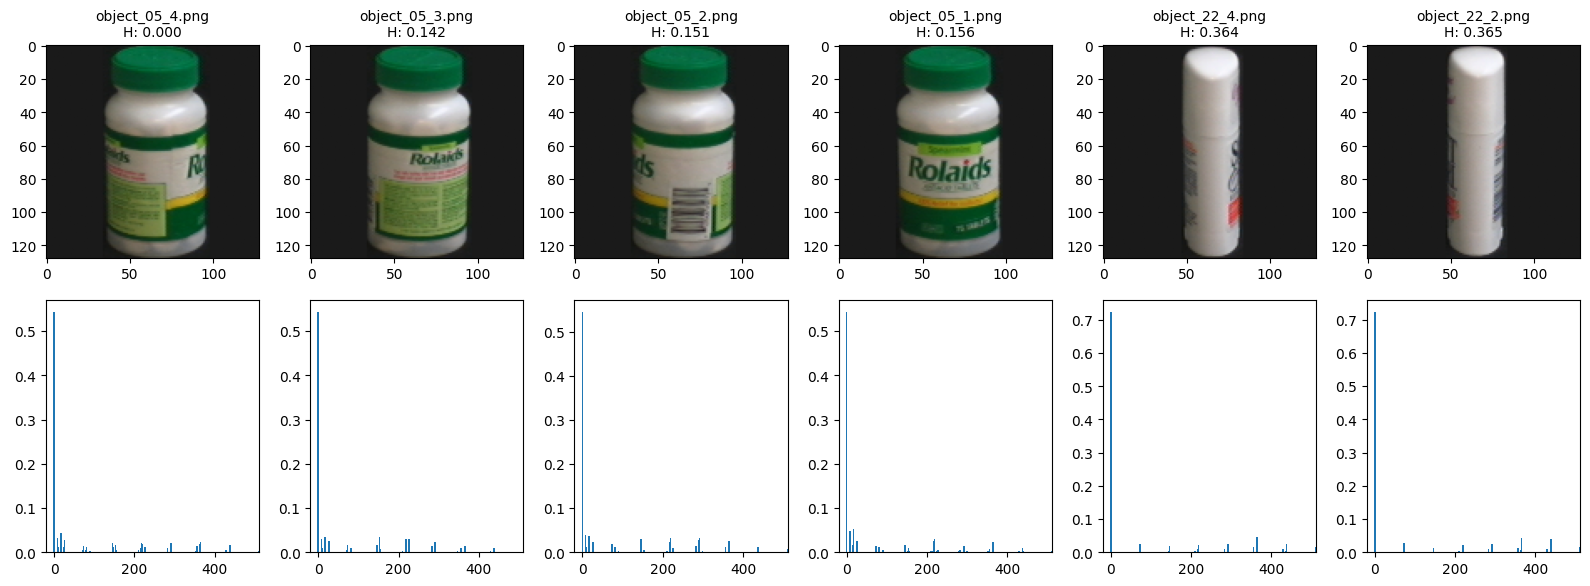

In [61]:
all_hists = np.load('histograms.npy')
ref = cv2.imread('./dataset/object_05_4.png')
ref = cv2.cvtColor(ref, cv2.COLOR_BGR2RGB).astype(np.float64)/255.0
ref_hist = myhist3(ref, 8).reshape(-1)
compare_withAll(ref_hist, 'H', all_hists)

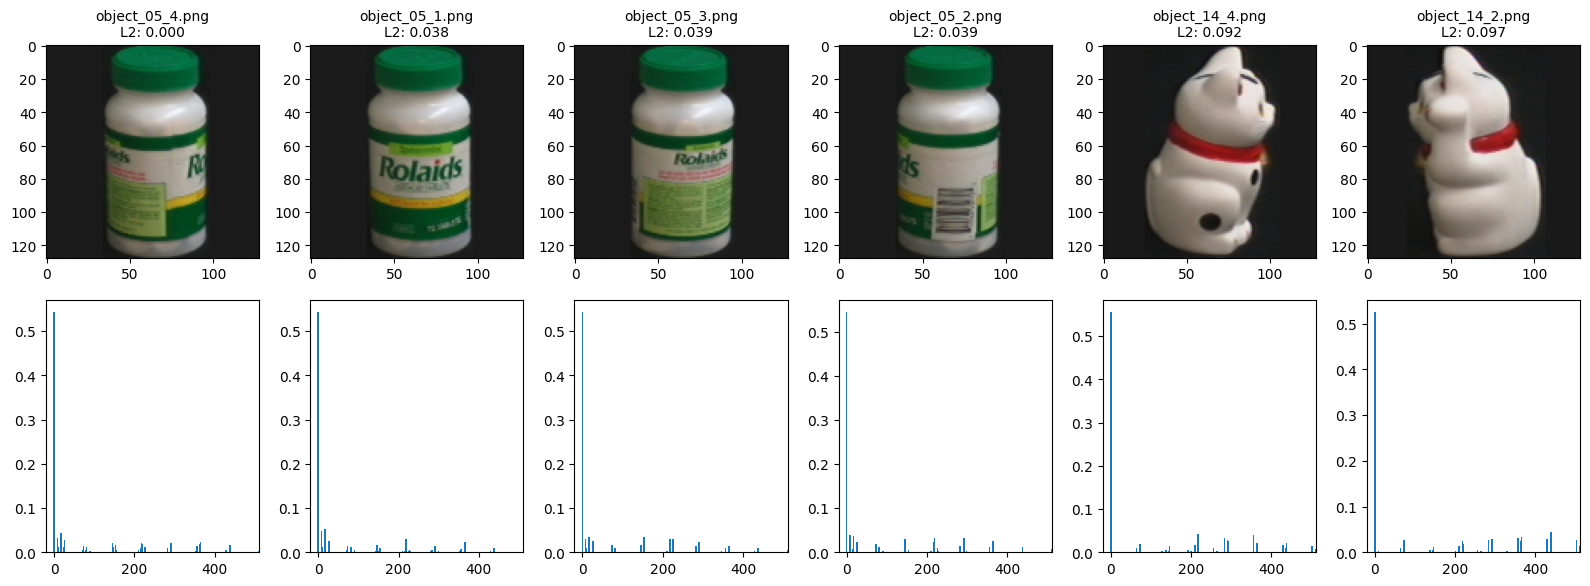

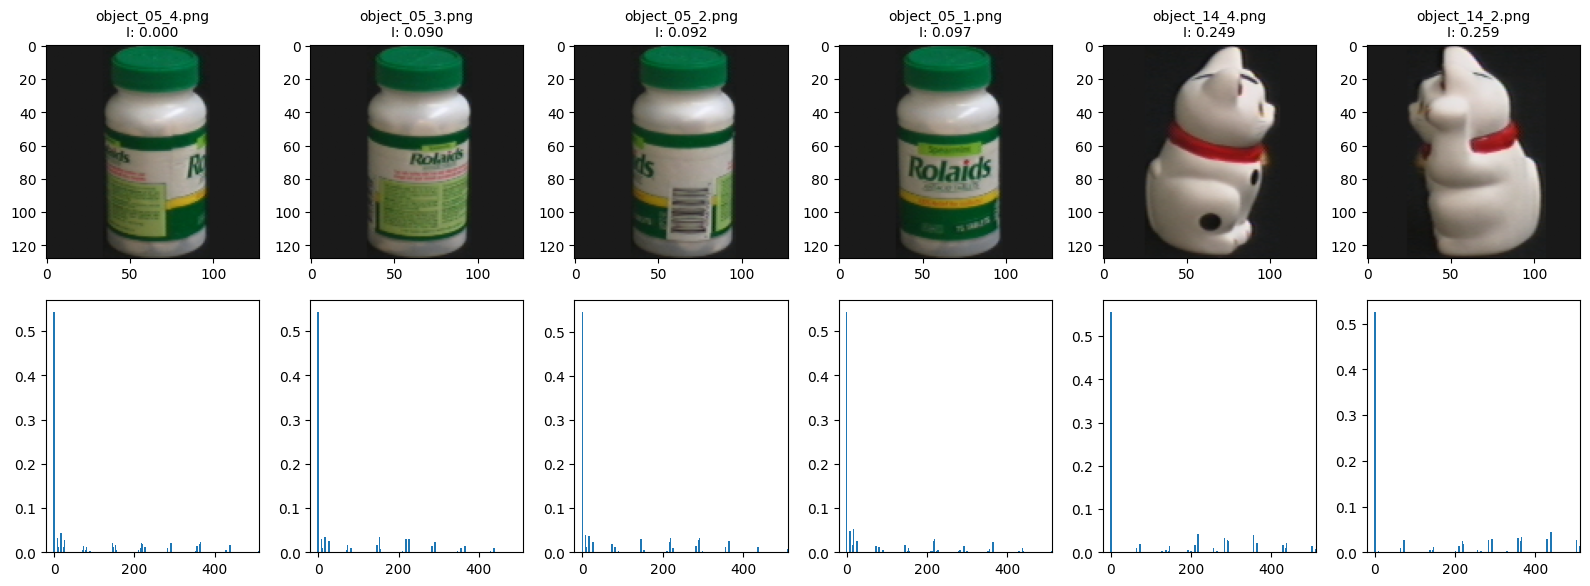

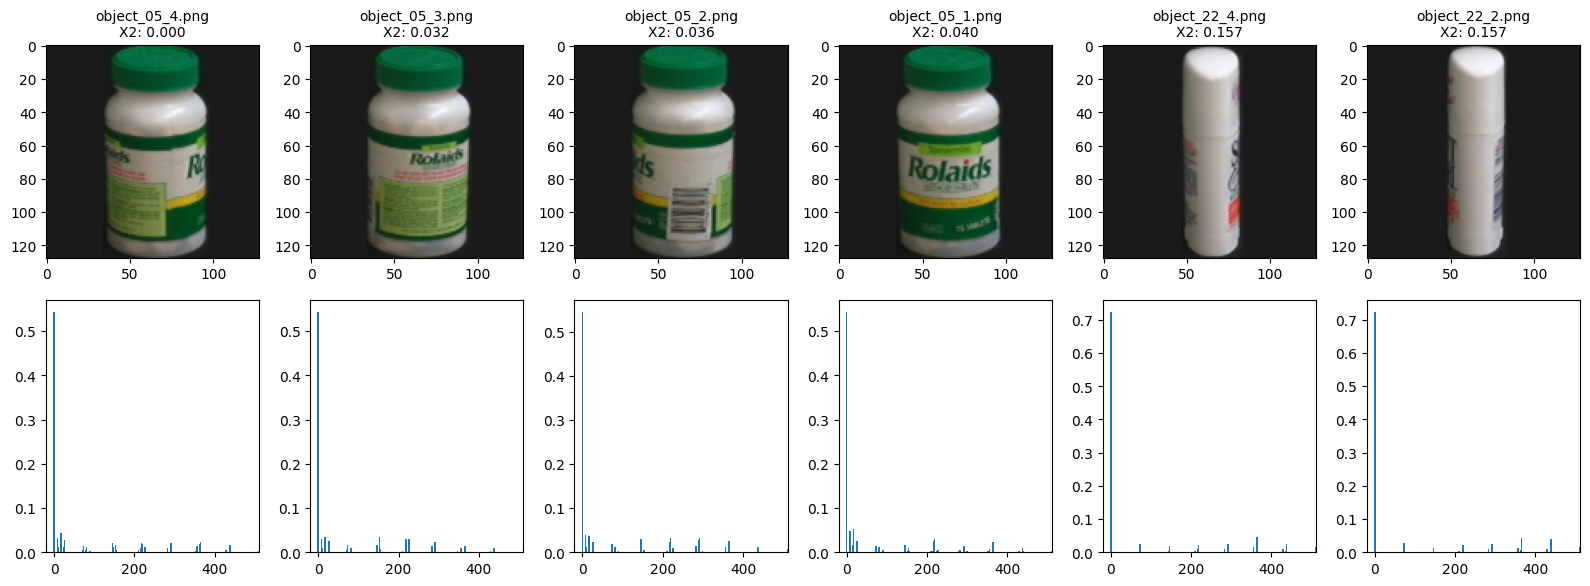

In [62]:
compare_withAll(ref_hist, 'L2', all_hists)
compare_withAll(ref_hist, 'I', all_hists)
compare_withAll(ref_hist, 'X2', all_hists)

**Question: Which distance is in your opinion best suited for image retrieval? How
does the retrieved sequence change if you use a different number of bins? Is the
execution time affected by the number of bins?**
The Hellinger distance. Changing the number of bins does not affect retrieving sequence, however it does affect which object is closer to the reference. Yes the time is affected.

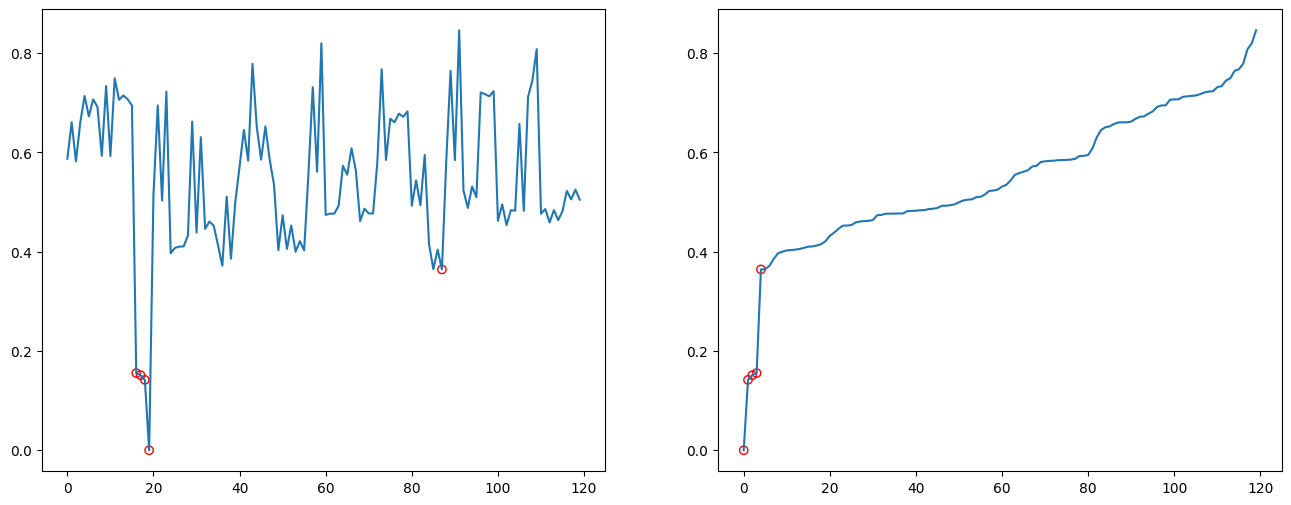

In [63]:
object05 = cv2.imread('./dataset/object_05_4.png')
object05 = cv2.cvtColor(object05, cv2.COLOR_BGR2RGB).astype(np.float64)/255.0
hist05 = myhist3(object05, 8).reshape(-1)
all_hists = np.load('histograms.npy')

distances = compute_distances(hist05, 'H',all_hists)
order = np.argsort(distances)
top5 = order[:5]

plt.figure(figsize=(16, 6))

plt.subplot(1,2,1)
plt.plot(np.arange(len(distances)), distances)
plt.scatter(top5, distances[top5], edgecolors='red', facecolors='none')

# urejeno
plt.subplot(1,2,2)
sorted_d = distances[order]
plt.plot(sorted_d)
plt.scatter(range(5), sorted_d[:5], edgecolors='red', facecolors='none')

plt.show()


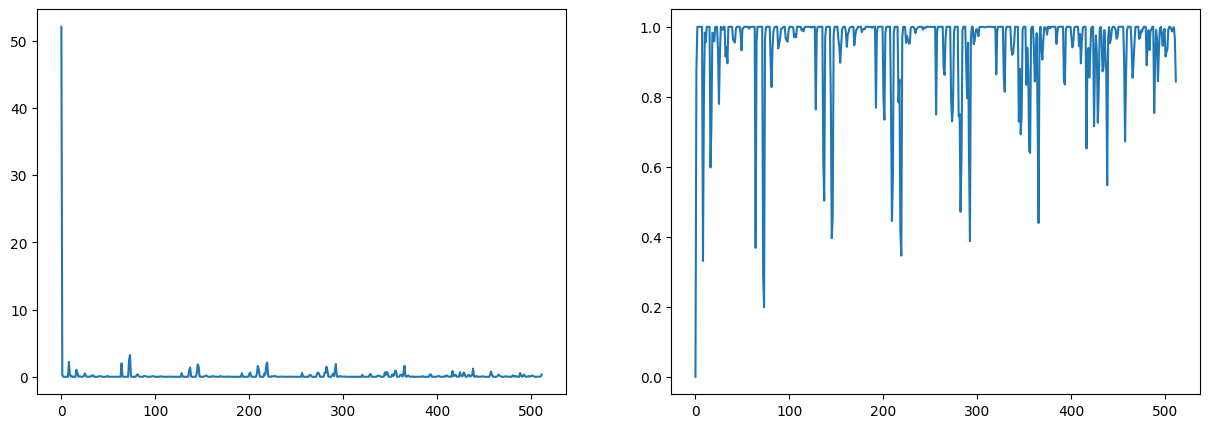

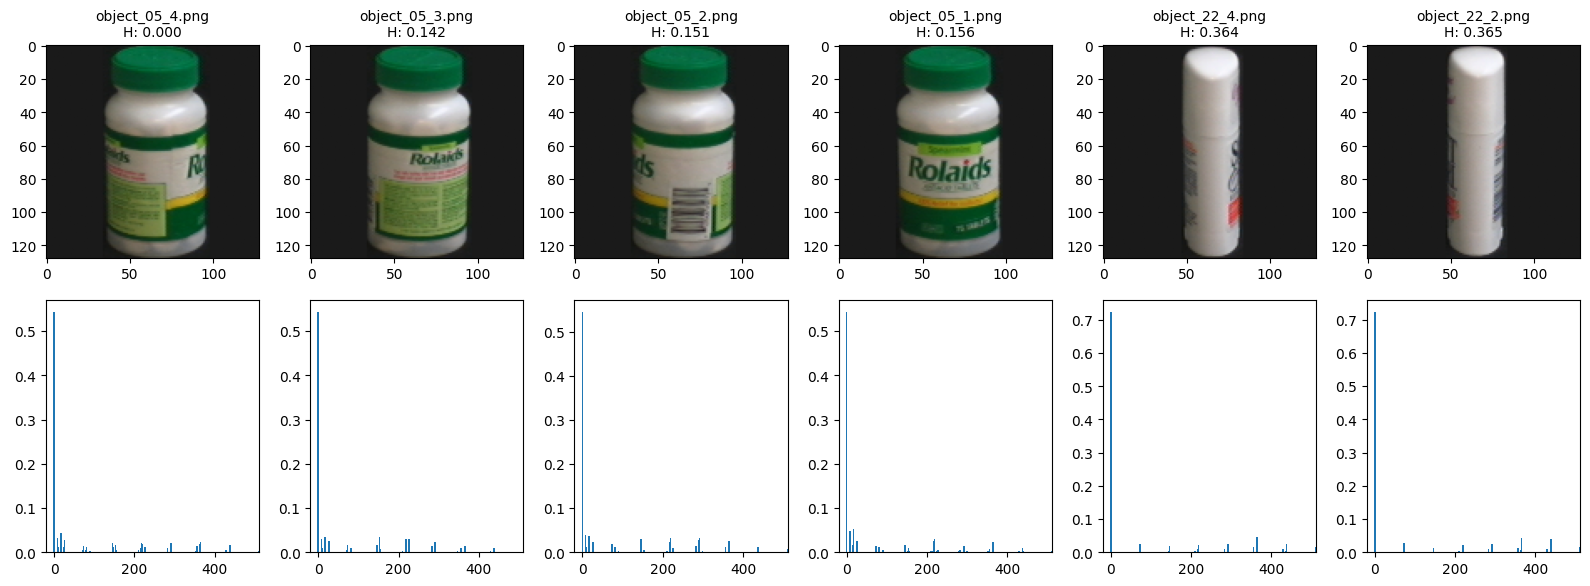

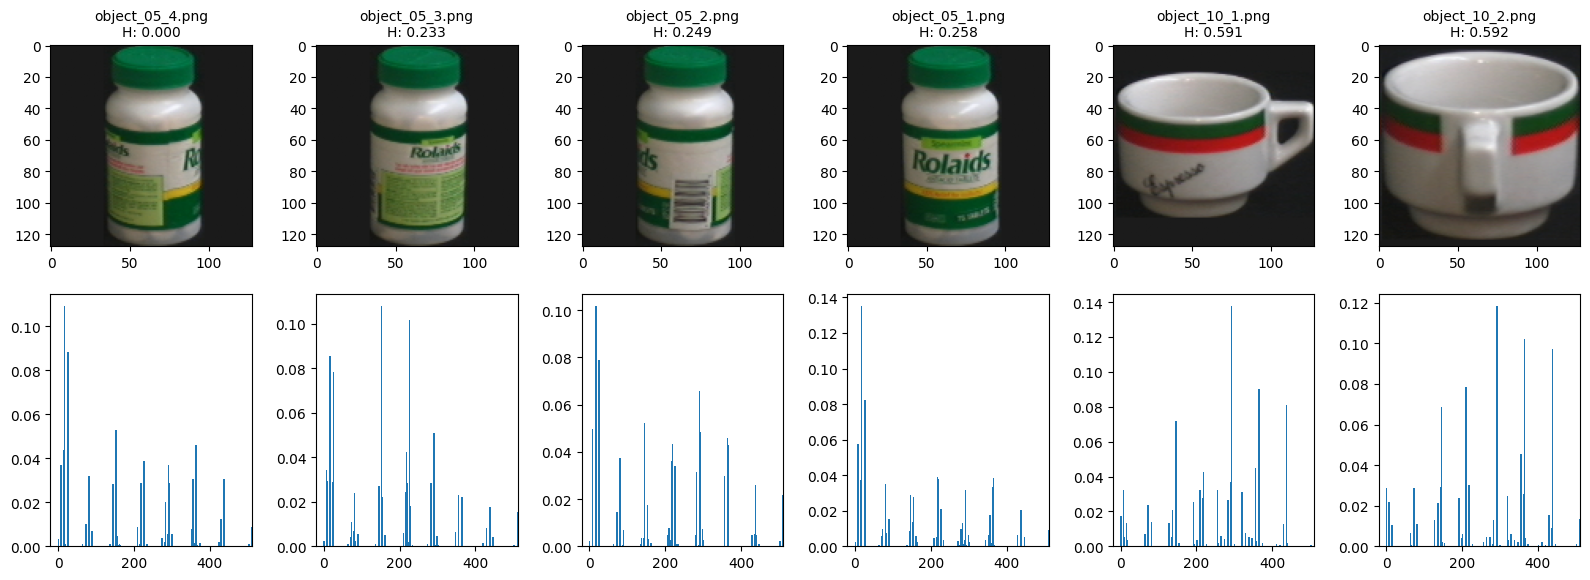

In [64]:
H = np.load('histograms.npy')
F = H.sum(axis=0)
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(F)

lam = 0.5
w_i = np.exp(-lam * F)

plt.subplot(1,2,2)
plt.plot(w_i)

Hw = H * w_i
Hw = Hw / Hw.sum(axis=1, keepdims=True)
np.save('histograms_weighted.npy', Hw)

hist05_w = ref_hist * w_i
hist05_w = hist05_w / hist05_w.sum()

compare_withAll(ref_hist, 'H', H)
compare_withAll(hist05_w, 'H', Hw)

**Which bins dominate this histogram?**
The first bin dominates the histogram.

**Compare the retrieval process for the weighted and the unweighted histograms. Report your observations. Did the weighting help with retrieving relevant results?**
When comparing the retrieval results for the weighted and unweighted histograms, we can observe that the weighting generally improves the retrieval performance.
In the unweighted case, the similarity scores (H values) are lower and do not always correspond to perceptually relevant matches.
After applying weighting, the retrieved images are more consistent with the query — objects with similar shape and color patterns appear higher in the ranking. The similarity scores (H values) are also higher and better reflect visual similarity.
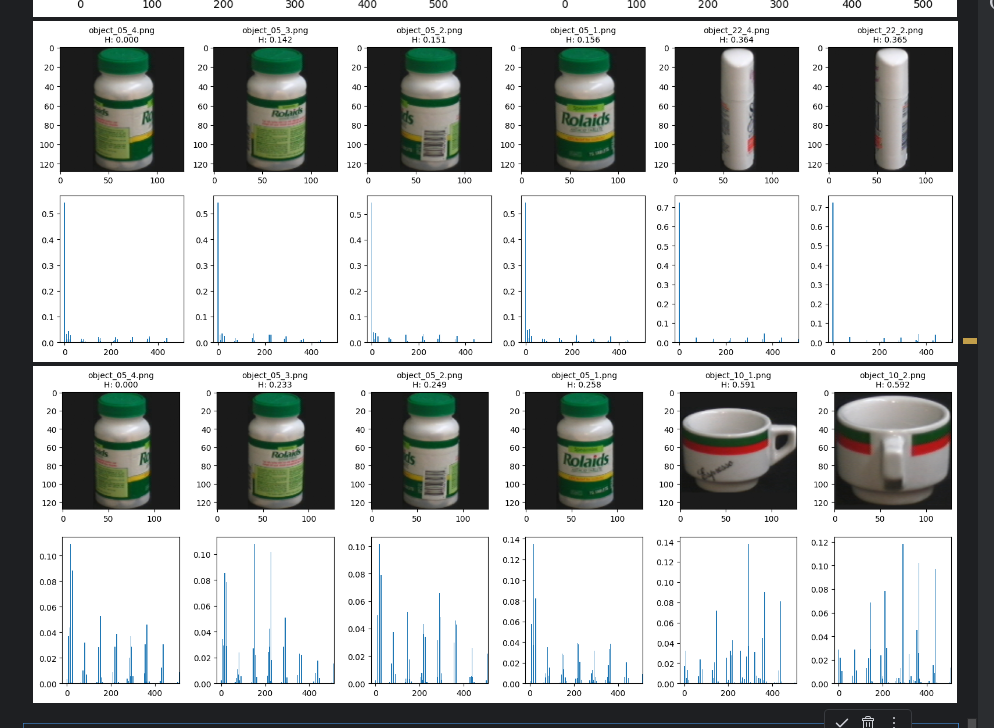